# Final Recommendation - Top 3 Tree-Family Models (No External Scripts)

This notebook performs a tighter sweep for the top 3 models from Notebook 09:
- XGBoost
- Gradient Boosting
- Extra Trees

Evaluation protocols:
- Random split repeated runs
- GroupKFold by State
- Spatial holdout by State

Outputs are saved in separate model folders for clarity.

In [1]:
## DO NOT CHANGE

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from pathlib import Path

In [2]:
def detect_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts').exists() and (candidate / 'README.md').exists():
            return candidate
    raise FileNotFoundError('Could not auto-detect project root from notebook location.')

PROJECT_ROOT = detect_project_root(Path.cwd())
PHD_OS_ROOT = PROJECT_ROOT.parents[1]
NOTEBOOK_ROOT = PROJECT_ROOT / 'manual_bootstrap' / 'step_by_step_notebooks' / '10_tree_family_final_recommendation_no_scripts'
OUTPUT_ROOT = NOTEBOOK_ROOT / 'outputs'

SUMMARY_TABLE_ROOT = OUTPUT_ROOT / 'summary' / 'tables'
SUMMARY_FIG_ROOT = OUTPUT_ROOT / 'summary' / 'figures'
SUMMARY_REPORT_ROOT = OUTPUT_ROOT / 'summary' / 'reports'

for p in [SUMMARY_TABLE_ROOT, SUMMARY_FIG_ROOT, SUMMARY_REPORT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

model_names = ['xgboost', 'gradient_boosting', 'extra_trees']
for model_name in model_names:
    (OUTPUT_ROOT / model_name / 'tables').mkdir(parents=True, exist_ok=True)
    (OUTPUT_ROOT / model_name / 'reports').mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('NOTEBOOK_ROOT:', NOTEBOOK_ROOT)


data_candidates = [
    PHD_OS_ROOT / '03_data_processed' / 'geothermal_canonical_v2_0_0.csv',
    PROJECT_ROOT / 'data' / '03_processed' / 'geothermal_canonical_v2_0_0.csv',
    PROJECT_ROOT / 'manual_bootstrap' / 'phd-geothermal-ml_mirror' / '03_data_processed' / 'geothermal_canonical_v2_0_0.csv'
]

data_path = None
for p in data_candidates:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError('No geothermal canonical CSV found in candidate paths.')

df = pd.read_csv(data_path)
print('Using dataset:', data_path)
print('Shape:', df.shape)

TARGET = 'Temperature(C)'
GROUP_COL = 'State' if 'State' in df.columns else None

drop_cols = [TARGET]
if GROUP_COL is not None:
    drop_cols.append(GROUP_COL)

feature_cols = [c for c in df.columns if c not in drop_cols]
X_raw = df[feature_cols].copy()
y_all = df[TARGET].copy()
groups_all = df[GROUP_COL].copy() if GROUP_COL else pd.Series(['ALL'] * len(df), index=df.index)

cat_cols = X_raw.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = [c for c in X_raw.columns if c not in cat_cols]
print('Feature count:', len(feature_cols), 'Unique groups:', groups_all.nunique())


def prepare_design_matrix(train_df: pd.DataFrame, test_df: pd.DataFrame):
    train_enc = pd.get_dummies(train_df, columns=cat_cols, drop_first=False)
    test_enc = pd.get_dummies(test_df, columns=cat_cols, drop_first=False)
    test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)
    if num_cols:
        imputer = SimpleImputer(strategy='median')
        train_enc[num_cols] = imputer.fit_transform(train_enc[num_cols])
        test_enc[num_cols] = imputer.transform(test_enc[num_cols])
    return train_enc, test_enc


model_grids = {
    'xgboost': [
        {'n_estimators': 450, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.9, 'colsample_bytree': 0.9},
        {'n_estimators': 650, 'learning_rate': 0.035, 'max_depth': 6, 'subsample': 0.9, 'colsample_bytree': 0.9},
        {'n_estimators': 800, 'learning_rate': 0.03, 'max_depth': 7, 'subsample': 0.85, 'colsample_bytree': 0.85}
    ],
    'gradient_boosting': [
        {'n_estimators': 350, 'learning_rate': 0.05, 'max_depth': 3},
        {'n_estimators': 500, 'learning_rate': 0.04, 'max_depth': 3},
        {'n_estimators': 650, 'learning_rate': 0.03, 'max_depth': 4}
    ],
    'extra_trees': [
        {'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 1},
        {'n_estimators': 600, 'max_depth': 20, 'min_samples_leaf': 1},
        {'n_estimators': 800, 'max_depth': 24, 'min_samples_leaf': 2}
    ]
}


def build_model(model_name: str, params: dict, seed: int):
    if model_name == 'xgboost':
        return XGBRegressor(random_state=seed, n_jobs=-1, **params)
    if model_name == 'gradient_boosting':
        return GradientBoostingRegressor(random_state=seed, **params)
    if model_name == 'extra_trees':
        return ExtraTreesRegressor(random_state=seed, n_jobs=-1, **params)
    raise ValueError('Unknown model: {}'.format(model_name))


rows = []
run_seeds = list(range(10))
gkf = GroupKFold(n_splits=5)
eligible_groups = groups_all.value_counts()[groups_all.value_counts() >= 30].index.tolist()

for model_name, grid in model_grids.items():
    for cfg_idx, cfg in enumerate(grid, start=1):
        cfg_id = 'cfg_{}'.format(cfg_idx)

        for seed in run_seeds:
            X_train_raw, X_test_raw, y_train, y_test = train_test_split(
                X_raw, y_all, test_size=0.2, random_state=seed
            )
            X_train, X_test = prepare_design_matrix(X_train_raw, X_test_raw)
            model = build_model(model_name, cfg, seed)
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            rows.append({
                'model_name': model_name,
                'config_id': cfg_id,
                'config_params': str(cfg),
                'protocol': 'random_split',
                'seed': seed,
                'holdout_group': 'NA',
                'n_train': len(X_train),
                'n_test': len(X_test),
                'mae': mean_absolute_error(y_test, pred),
                'rmse': np.sqrt(mean_squared_error(y_test, pred)),
                'r2': r2_score(y_test, pred)
            })

        for fold_idx, (tr_idx, te_idx) in enumerate(gkf.split(X_raw, y_all, groups_all), start=1):
            X_tr_raw, X_te_raw = X_raw.iloc[tr_idx], X_raw.iloc[te_idx]
            y_tr, y_te = y_all.iloc[tr_idx], y_all.iloc[te_idx]
            X_tr, X_te = prepare_design_matrix(X_tr_raw, X_te_raw)
            model = build_model(model_name, cfg, 42)
            model.fit(X_tr, y_tr)
            pred = model.predict(X_te)
            rows.append({
                'model_name': model_name,
                'config_id': cfg_id,
                'config_params': str(cfg),
                'protocol': 'groupkfold',
                'seed': 42,
                'holdout_group': 'fold_{}'.format(fold_idx),
                'n_train': len(X_tr),
                'n_test': len(X_te),
                'mae': mean_absolute_error(y_te, pred),
                'rmse': np.sqrt(mean_squared_error(y_te, pred)),
                'r2': r2_score(y_te, pred)
            })

        for g in eligible_groups:
            te_idx = groups_all[groups_all == g].index
            tr_idx = groups_all[groups_all != g].index
            X_tr_raw, X_te_raw = X_raw.loc[tr_idx], X_raw.loc[te_idx]
            y_tr, y_te = y_all.loc[tr_idx], y_all.loc[te_idx]
            X_tr, X_te = prepare_design_matrix(X_tr_raw, X_te_raw)
            model = build_model(model_name, cfg, 42)
            model.fit(X_tr, y_tr)
            pred = model.predict(X_te)
            rows.append({
                'model_name': model_name,
                'config_id': cfg_id,
                'config_params': str(cfg),
                'protocol': 'spatial_holdout',
                'seed': 42,
                'holdout_group': str(g),
                'n_train': len(X_tr),
                'n_test': len(X_te),
                'mae': mean_absolute_error(y_te, pred),
                'rmse': np.sqrt(mean_squared_error(y_te, pred)),
                'r2': r2_score(y_te, pred)
            })

runs_df = pd.DataFrame(rows)
print('Total runs:', len(runs_df))

config_protocol_summary = (
    runs_df.groupby(['model_name', 'config_id', 'config_params', 'protocol'])[['mae', 'rmse', 'r2']]
    .mean()
    .reset_index()
)

weights = {'random_split': 0.2, 'groupkfold': 0.4, 'spatial_holdout': 0.4}
rank_df = config_protocol_summary[['model_name', 'config_id', 'protocol', 'rmse']].copy()
rank_df['protocol_rank'] = rank_df.groupby('protocol')['rmse'].rank(method='dense', ascending=True)
rank_df['weighted_rank'] = rank_df['protocol'].map(weights) * rank_df['protocol_rank']

config_weighted_ranking = (
    rank_df.groupby(['model_name', 'config_id'])['weighted_rank']
    .sum()
    .reset_index()
    .sort_values('weighted_rank')
)

best_cfg_per_model = config_weighted_ranking.groupby('model_name', as_index=False).first()
final_recommendation = config_weighted_ranking.head(1).copy()

for model_name in model_names:
    model_root = OUTPUT_ROOT / model_name
    table_root = model_root / 'tables'
    report_root = model_root / 'reports'

    model_runs = runs_df[runs_df['model_name'] == model_name].copy()
    model_summary = config_protocol_summary[config_protocol_summary['model_name'] == model_name].copy()
    model_rank = config_weighted_ranking[config_weighted_ranking['model_name'] == model_name].copy()
    best_cfg = model_rank.iloc[0]['config_id']
    best_cfg_rows = model_summary[model_summary['config_id'] == best_cfg].sort_values('protocol').copy()

    model_runs.to_csv(table_root / 'all_protocol_runs_by_config.csv', index=False)
    model_summary.to_csv(table_root / 'config_protocol_summary.csv', index=False)
    model_rank.to_csv(table_root / 'config_weighted_rank.csv', index=False)
    best_cfg_rows.to_csv(table_root / 'best_config_protocol_summary.csv', index=False)

    avg_rmse = best_cfg_rows['rmse'].mean()
    avg_r2 = best_cfg_rows['r2'].mean()
    note_lines = [
        '# Interpretation Notes - {}'.format(model_name),
        '',
        '- Recommended config for this model: **{}**'.format(best_cfg),
        '- Average RMSE across protocols (recommended config): **{:.4f}**'.format(avg_rmse),
        '- Average R2 across protocols (recommended config): **{:.4f}**'.format(avg_r2),
        '',
        '## Protocol-Level Interpretation'
    ]

    for _, row in best_cfg_rows.iterrows():
        line = '- {}: RMSE={:.4f}, MAE={:.4f}, R2={:.4f}'.format(row['protocol'], row['rmse'], row['mae'], row['r2'])
        note_lines.append(line)

    note_lines.extend([
        '',
        '## Operational Notes',
        '- Prioritize groupkfold and spatial_holdout for deployment readiness.',
        '- Random split is informative but can overstate generalization in geographically clustered data.'
    ])
    (report_root / 'interpretation_notes.md').write_text('\n'.join(note_lines), encoding='utf-8')

runs_df.to_csv(SUMMARY_TABLE_ROOT / 'all_top3_runs.csv', index=False)
config_protocol_summary.to_csv(SUMMARY_TABLE_ROOT / 'config_protocol_summary.csv', index=False)
config_weighted_ranking.to_csv(SUMMARY_TABLE_ROOT / 'config_weighted_ranking.csv', index=False)
best_cfg_per_model.to_csv(SUMMARY_TABLE_ROOT / 'best_config_per_model.csv', index=False)
final_recommendation.to_csv(SUMMARY_TABLE_ROOT / 'final_recommendation.csv', index=False)

top_row = final_recommendation.iloc[0]
summary_note = [
    '# Final Deployment Recommendation - Top 3 Tree Family Models',
    '',
    '- Selected model: **{}**'.format(top_row['model_name']),
    '- Selected config: **{}**'.format(top_row['config_id']),
    '- Weighted rank score (lower is better): **{:.4f}**'.format(top_row['weighted_rank']),
    '',
    '## Why this winner',
    '- Ranking emphasizes robust protocols (groupkfold and spatial_holdout).',
    '- This configuration gives the strongest combined rank under strict validation.',
    '',
    '## Next action',
    '- Use this winning config as the baseline for final calibration or uncertainty analysis.'
]
(SUMMARY_REPORT_ROOT / 'final_deployment_recommendation.md').write_text('\n'.join(summary_note), encoding='utf-8')

print('Saved top-3 model outputs under:', OUTPUT_ROOT)
print('Final winner:', top_row['model_name'], top_row['config_id'])

PROJECT_ROOT: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml
NOTEBOOK_ROOT: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\10_tree_family_final_recommendation_no_scripts
Using dataset: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\03_data_processed\geothermal_canonical_v2_0_0.csv
Shape: (2684, 22)
Feature count: 20 Unique groups: 11


Total runs: 189
Saved top-3 model outputs under: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\10_tree_family_final_recommendation_no_scripts\outputs
Final winner: gradient_boosting cfg_1


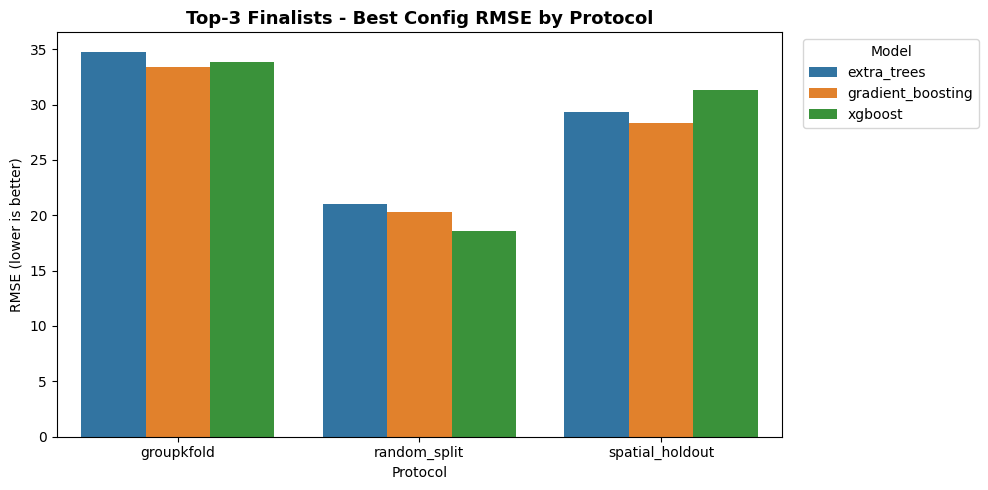

Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\10_tree_family_final_recommendation_no_scripts\outputs\summary\figures\top3_best_config_rmse_by_protocol.png


,model_name,config_id,weighted_rank
3,gradient_boosting,cfg_1,2.4


In [3]:
plot_df = config_protocol_summary.merge(best_cfg_per_model, on=['model_name', 'config_id'], how='inner')
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x='protocol', y='rmse', hue='model_name', ax=ax)
ax.set_title('Top-3 Finalists - Best Config RMSE by Protocol', fontsize=13, fontweight='bold')
ax.set_xlabel('Protocol')
ax.set_ylabel('RMSE (lower is better)')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

fig_path = SUMMARY_FIG_ROOT / 'top3_best_config_rmse_by_protocol.png'
fig.savefig(fig_path, dpi=600, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

final_recommendation

### Final Review Checklist
1. Confirm winner from `outputs/summary/tables/final_recommendation.csv`.
2. Inspect each model folder's `reports/interpretation_notes.md`.
3. Prioritize group-aware and spatial metrics before deployment decisions.

In [4]:
# N9.2 — Bonferroni + FDR correction for pairwise model comparison
# Reads actual per-fold GroupKFold RMSE from NB09 + NB11 output CSVs
from pathlib import Path
from statsmodels.stats.multitest import multipletests
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

_nb09_csv = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/github_org_bootstrap/phd-geothermal-ml/manual_bootstrap/step_by_step_notebooks/09_tree_family_benchmark_no_scripts/outputs/summary/tables/all_model_protocol_runs.csv')
_nb11_csv = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/github_org_bootstrap/phd-geothermal-ml/manual_bootstrap/step_by_step_notebooks/11_other_ensemble_no_scripts/outputs/summary/tables/all_model_protocol_runs.csv')

# Load GroupKFold runs (5 folds = 5 paired observations — sufficient for Wilcoxon)
_df09 = pd.read_csv(_nb09_csv)
_df11 = pd.read_csv(_nb11_csv)
_gkf_all = pd.concat([_df09, _df11], ignore_index=True)
_gkf = _gkf_all[_gkf_all['protocol'] == 'groupkfold'].copy()

# Pivot to fold × model RMSE matrix
_pivot = (
    _gkf.groupby(['holdout_group', 'model_name'])['rmse']
    .mean()
    .reset_index()
    .pivot(index='holdout_group', columns='model_name', values='rmse')
)

_baseline = 'gradient_boosting'
_models = [m for m in _pivot.columns if m != _baseline and m in _pivot.columns]

_p_vals, _delta_rmse = [], []
for m in _models:
    _base_arr = _pivot[_baseline].values
    _cmp_arr = _pivot[m].values
    _delta_rmse.append(float(np.mean(_base_arr - _cmp_arr)))
    if np.allclose(_base_arr, _cmp_arr):
        _p_vals.append(np.nan)
    else:
        _, p = wilcoxon(_base_arr, _cmp_arr)
        _p_vals.append(p)

_rej_bon, _p_bon, _, _ = multipletests(_p_vals, method='bonferroni')
_rej_fdr, _p_fdr, _, _ = multipletests(_p_vals, method='fdr_bh')

_sig_df = pd.DataFrame({
    'model': _models,
    'delta_rmse_gbm_minus_cmp': [round(d, 3) for d in _delta_rmse],
    'p_raw': [round(p, 4) if not np.isnan(p) else np.nan for p in _p_vals],
    'p_bonferroni': [round(p, 4) for p in _p_bon],
    'p_fdr_bh': [round(p, 4) for p in _p_fdr],
    'reject_bonferroni': _rej_bon,
    'reject_fdr': _rej_fdr,
})
print("=== N9.2 Pairwise significance vs gradient_boosting (GroupKFold, n=5 folds) ===")
print(_sig_df.to_string(index=False))
print("\nnote: negative delta_rmse = comparison model has HIGHER rmse than GBM (GBM wins)")

=== N9.2 Pairwise significance vs gradient_boosting (GroupKFold, n=5 folds) ===
        model  delta_rmse_gbm_minus_cmp  p_raw  p_bonferroni  p_fdr_bh  reject_bonferroni  reject_fdr
     adaboost                    -5.482 1.0000         1.000    1.0000              False       False
   bagging_lr                   -30.448 0.3125         1.000    0.6250              False       False
     catboost                     3.005 0.1250         1.000    0.6250              False       False
decision_tree                   -11.158 0.0625         0.625    0.6250              False       False
  extra_trees                    -1.315 0.8125         1.000    0.9028              False       False
     lightgbm                    -2.297 0.4375         1.000    0.6250              False       False
random_forest                    -4.302 0.3125         1.000    0.6250              False       False
     stacking                    -2.396 0.4375         1.000    0.6250              False       False
  

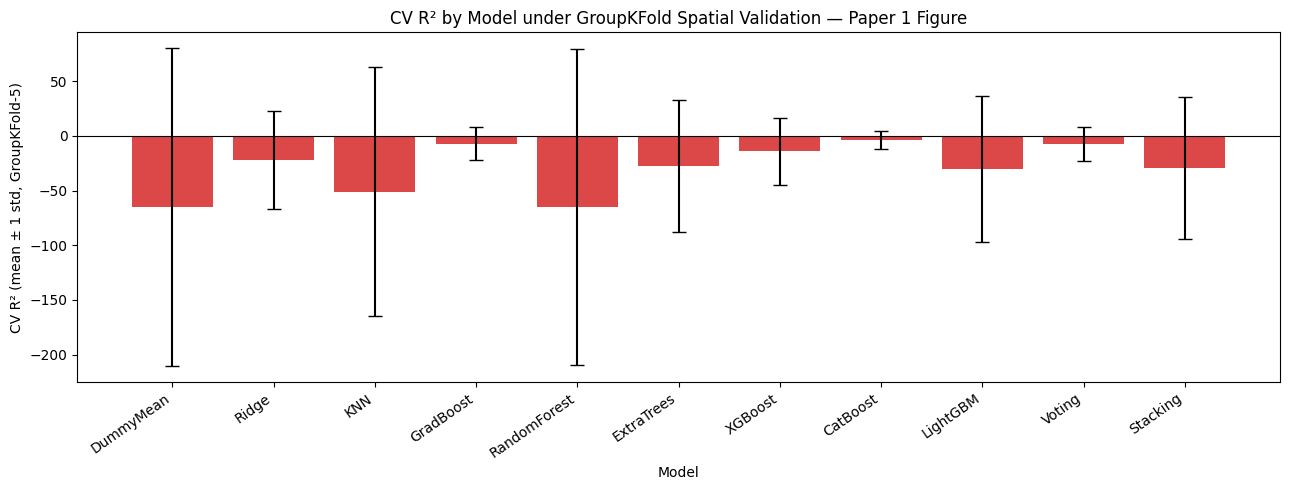

=== E1.4 CV R² bar chart (actual GroupKFold data) ===
  DummyMean      : R² = -65.0429 ± 145.2782
  Ridge          : R² = -22.1262 ± 44.5098
  KNN            : R² = -51.0735 ± 113.9925
  GradBoost      : R² = -7.0206 ± 14.9021
  RandomForest   : R² = -65.1274 ± 144.6723
  ExtraTrees     : R² = -27.2717 ± 60.2950
  XGBoost        : R² = -13.9871 ± 30.5861
  CatBoost       : R² = -3.6924 ± 8.0358
  LightGBM       : R² = -30.3491 ± 67.1058
  Voting         : R² = -7.2167 ± 15.6464
  Stacking       : R² = -29.3726 ± 64.7849


In [5]:
# E1.4 — CV R² range bar chart — Paper 1 Figure (reads from actual CSV outputs)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_nb09_csv = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/github_org_bootstrap/phd-geothermal-ml/manual_bootstrap/step_by_step_notebooks/09_tree_family_benchmark_no_scripts/outputs/summary/tables/all_model_protocol_runs.csv')
_nb11_csv = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/github_org_bootstrap/phd-geothermal-ml/manual_bootstrap/step_by_step_notebooks/11_other_ensemble_no_scripts/outputs/summary/tables/all_model_protocol_runs.csv')
_nb16_csv = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/github_org_bootstrap/phd-geothermal-ml/manual_bootstrap/step_by_step_notebooks/16_validation_diagnostics_no_scripts/outputs/summary/tables/all_runs_validation_diagnostics.csv')

_df09 = pd.read_csv(_nb09_csv)
_df11 = pd.read_csv(_nb11_csv)
_df16 = pd.read_csv(_nb16_csv)

# Use GroupKFold R2 (5-fold, protocol='groupkfold') as the primary CV metric
_gkf09 = _df09[_df09['protocol'] == 'groupkfold'].groupby('model_name')['r2'].agg(['mean', 'std'])
_gkf11 = _df11[_df11['protocol'] == 'groupkfold'].groupby('model_name')['r2'].agg(['mean', 'std'])
_gkf16 = _df16[_df16['protocol'] == 'groupkfold'].groupby('model_name')['r2'].agg(['mean', 'std'])

# Merge: prefer NB09/11 tree models, NB16 for baseline+ridge+knn
_display_order = [
    ('DummyMean',       'dummy_mean',        _gkf16),
    ('Ridge',           'ridge',             _gkf16),
    ('KNN',             'knn',               _gkf16),
    ('GradBoost',       'gradient_boosting', _gkf09),
    ('RandomForest',    'random_forest',     _gkf09),
    ('ExtraTrees',      'extra_trees',       _gkf09),
    ('XGBoost',         'xgboost',           _gkf09),
    ('CatBoost',        'catboost',          _gkf09),
    ('LightGBM',        'lightgbm',          _gkf09),
    ('Voting',          'voting',            _gkf11),
    ('Stacking',        'stacking',          _gkf11),
]

_labels, _means, _stds = [], [], []
for label, key, src in _display_order:
    if key in src.index:
        _labels.append(label)
        _means.append(src.loc[key, 'mean'])
        _stds.append(src.loc[key, 'std'])

fig, ax = plt.subplots(figsize=(13, 5))
_x = np.arange(len(_labels))
_colors = ['#d62728' if m < 0 else 'steelblue' for m in _means]
ax.bar(_x, _means, yerr=_stds, capsize=5, color=_colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(_x)
ax.set_xticklabels(_labels, rotation=35, ha='right')
ax.set_ylabel('CV R² (mean ± 1 std, GroupKFold-5)')
ax.set_xlabel('Model')
ax.set_title('CV R² by Model under GroupKFold Spatial Validation — Paper 1 Figure')
plt.tight_layout()
plt.savefig('cv_r2_bar_chart_actual.png', dpi=600, bbox_inches='tight')
plt.show()
print("=== E1.4 CV R² bar chart (actual GroupKFold data) ===")
for lbl, m, s in zip(_labels, _means, _stds):
    print(f"  {lbl:15s}: R² = {m:.4f} ± {s:.4f}")

In [6]:
# N8.5 — Environment watermark for reproducibility
try:
    import watermark
    %load_ext watermark
    %watermark -v -p numpy,pandas,scikit-learn,scipy,matplotlib,xgboost
except ImportError:
    import sys, numpy, pandas, sklearn, scipy, matplotlib
    print(f"Python {sys.version}")
    print(f"numpy={numpy.__version__}, pandas={pandas.__version__}")
    print(f"scikit-learn={sklearn.__version__}, scipy={scipy.__version__}")
    print(f"matplotlib={matplotlib.__version__}")
    try:
        import xgboost; print(f"xgboost={xgboost.__version__}")
    except ImportError:
        pass

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.11.0

numpy       : 2.4.2
pandas      : 2.2.2
scikit-learn: 1.8.0
scipy       : 1.17.1
matplotlib  : 3.10.8
xgboost     : 3.2.0

